# 数据集点云格式对比分析

本notebook用于比较两个数据集的点云格式：
1. opv2v数据集: `/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test`
2. v2v4real数据集: `/home/labeling/datasets/v2v4real_data_dumping`

In [16]:
import sys
import os

# 添加OpenCOOD到Python路径
current_dir = os.path.dirname(os.path.abspath('__file__'))
sys.path.append(current_dir)

import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
import open3d as o3d

# 设置路径
OPV2V_PATH = "/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test"
V2V4REAL_PATH = "/home/labeling/datasets/v2v4real_data_dumping"

# 导入OpenCOOD的工具函数
from opencood.hypes_yaml.yaml_utils import load_yaml

## 1. 加载并分析YAML文件

In [17]:
def lidar_matrix_to_pose(matrix):
    """
    Convert 4x4 transformation matrix to [x, y, z, roll, yaw, pitch]
    """
    x = matrix[0, 3]
    y = matrix[1, 3]
    z = matrix[2, 3]
    
    # Extract rotation angles from matrix
    pitch = np.arcsin(matrix[2, 0])
    yaw = np.arctan2(matrix[1, 0], matrix[0, 0])
    roll = np.arctan2(-matrix[2, 1], matrix[2, 2])
    
    return [x, y, z, np.degrees(roll), np.degrees(yaw), np.degrees(pitch)]


def analyze_lidar_data(yaml_data):
    """分析点云数据的格式和统计信息"""
    if 'lidar_pose' in yaml_data:
        lidar_data = np.array(yaml_data['lidar_pose'])
        
        # 检查是否为4x4矩阵形式
        if len(lidar_data.shape) == 2 and lidar_data.shape == (4,4):
            print("检测到4x4矩阵形式的LiDAR位姿")
            lidar_data = lidar_matrix_to_pose(lidar_data)
        # 检查是否为[x,y,z,roll,yaw,pitch]形式  
        elif len(lidar_data.shape) == 1 and lidar_data.shape[0] == 6:
            print("检测到[x,y,z,roll,yaw,pitch]形式的LiDAR位姿")
        print(f"位置: [{lidar_data[0]:.2f}, {lidar_data[1]:.2f}, {lidar_data[2]:.2f}]")
        print(f"姿态(roll,yaw,pitch): [{lidar_data[3]:.2f}, {lidar_data[4]:.2f}, {lidar_data[5]:.2f}]")
        return lidar_data
    return None

## 2. 分析opv2v数据集

In [3]:
# 获取opv2v数据集的一个样本
opv2v_sample = '/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1045/000068.yaml'
print(f"分析opv2v样本: {opv2v_sample}")

opv2v_data = load_yaml(opv2v_sample)
opv2v_lidar = analyze_lidar_data(opv2v_data)

分析opv2v样本: /home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1045/000068.yaml
检测到[x,y,z,roll,yaw,pitch]形式的LiDAR位姿
位置: [599.71, -17.01, 1.93]
姿态(roll,yaw,pitch): [0.02, -178.53, 0.21]


## 3. 分析v2v4real数据集

In [18]:
# 获取v2v4real数据集的一个样本
v2v4real_sample = '/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/0/000146.yaml'
print(f"分析v2v4real样本: {v2v4real_sample}")

v2v4real_data = load_yaml(v2v4real_sample)
v2v4real_lidar = analyze_lidar_data(v2v4real_data)

分析v2v4real样本: /home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/0/000146.yaml
检测到4x4矩阵形式的LiDAR位姿
位置: [-104.84, 932.72, 8.20]
姿态(roll,yaw,pitch): [-2.25, 84.79, -1.78]


## 4. 可视化点云数据

In [5]:
import plotly.graph_objs as go
import numpy as np
import open3d as o3d

def plot_point_cloud_plotly(pcd_path):
    pcd = o3d.io.read_point_cloud(pcd_path)
    points = np.asarray(pcd.points)

    fig = go.Figure(data=[go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode='markers',
        marker=dict(size=1, color='cyan')
    )])
    fig.update_layout(title='Point Cloud (Plotly)', scene=dict(aspectmode='data'))
    fig.show()


In [6]:
v2v4real_pcd_pth = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-15-09-54-40_0/0/000145.pcd"
opv2v_pcd_pth = "/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1045/000068.pcd"

In [ ]:
plot_point_cloud_plotly(v2v4real_pcd_pth)

In [ ]:
plot_point_cloud_plotly(opv2v_pcd_pth)

## 5. BEV图看V2V4Real中两车跨车坐标是否对齐

In [28]:
def transform_points_from_euler(points, pose_euler, degrees=True):
    """
    使用 [x, y, z, roll, yaw, pitch] 表示的位姿将点云变换到全局坐标系
    pose_euler: [x, y, z, roll, yaw, pitch]
    degrees: 是否为角度制
    """
    x, y, z, roll, yaw, pitch = pose_euler

    # 注意顺序：roll=pitch=yaw 需要用 R.from_euler
    if degrees:
        rotation = R.from_euler('xyz', [roll, pitch, yaw], degrees=True)
    else:
        rotation = R.from_euler('xyz', [roll, pitch, yaw], degrees=False)

    rot_matrix = rotation.as_matrix()  # (3,3)

    # 构建 4x4 变换矩阵
    transform = np.eye(4)
    transform[:3, :3] = rot_matrix
    transform[:3, 3] = [x, y, z]

    # 应用变换
    N = points.shape[0]
    homo = np.hstack([points, np.ones((N, 1))])  # (N, 4)
    transformed = (transform @ homo.T).T[:, :3]

    return transformed


def transform_points_from_matrix(points, matrix):
    """
    Use 4x4 transformation matrix to transform points
    """
    N = points.shape[0]
    homo = np.hstack([points, np.ones((N, 1))])  # (N, 4)
    transformed = (matrix @ homo.T).T[:, :3]
    return transformed


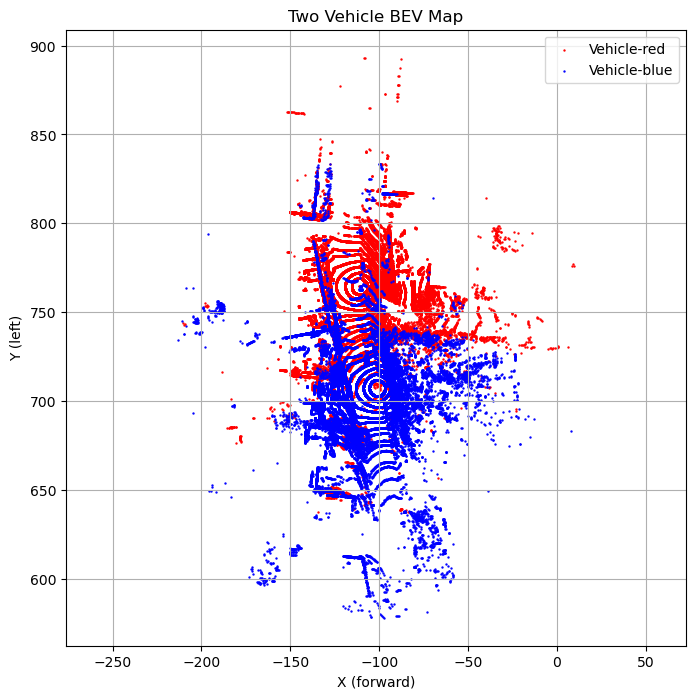

In [29]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def load_pose_from_yaml(yaml_path):
    pose = load_yaml(yaml_path)['lidar_pose']
    if isinstance(pose, np.ndarray) and pose.shape == (4, 4):
        return pose
    elif isinstance(pose, list) and len(pose) == 6:
        return pose
    else:
        raise ValueError(f"Invalid lidar_pose shape: {pose.shape}")

def load_pcd_points(pcd_path):
    pcd = o3d.io.read_point_cloud(pcd_path)
    return np.asarray(pcd.points)

def plot_bev_map(points_list, colors, title="BEV Map"):
    plt.figure(figsize=(8, 8))
    for points, color in zip(points_list, colors):
        plt.scatter(points[:, 0], points[:, 1], s=0.5, c=color, label=f"Vehicle-{color}")
    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.grid(True)
    plt.show()

# === 路径填写区域 ===
pcd1_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/0/000000.pcd"
yaml1_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/0/000000.yaml"
pcd2_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/1/000000.pcd"
yaml2_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/1/000000.yaml"

# pcd1_path = "/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1045/000262.pcd"
# yaml1_path = "/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1045/000262.yaml"
# pcd2_path = "/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1054/000262.pcd"
# yaml2_path = "/home/labeling/datasets/opv2v_data_dumping/test/test_chunks/test/2021_08_18_19_48_05/1054/000262.yaml"

# === 主流程 ===
# pose1 = lidar_matrix_to_pose(load_pose_from_yaml(yaml1_path))
# pose2 = lidar_matrix_to_pose(load_pose_from_yaml(yaml2_path))
pose1 = load_pose_from_yaml(yaml1_path)
pose2 = load_pose_from_yaml(yaml2_path)
points1 = load_pcd_points(pcd1_path)
points2 = load_pcd_points(pcd2_path)

points1_world = transform_points_from_matrix(points1, pose1)
points2_world = transform_points_from_matrix(points2, pose2)

plot_bev_map([points1_world, points2_world], colors=["red", "blue"], title="Two Vehicle BEV Map")

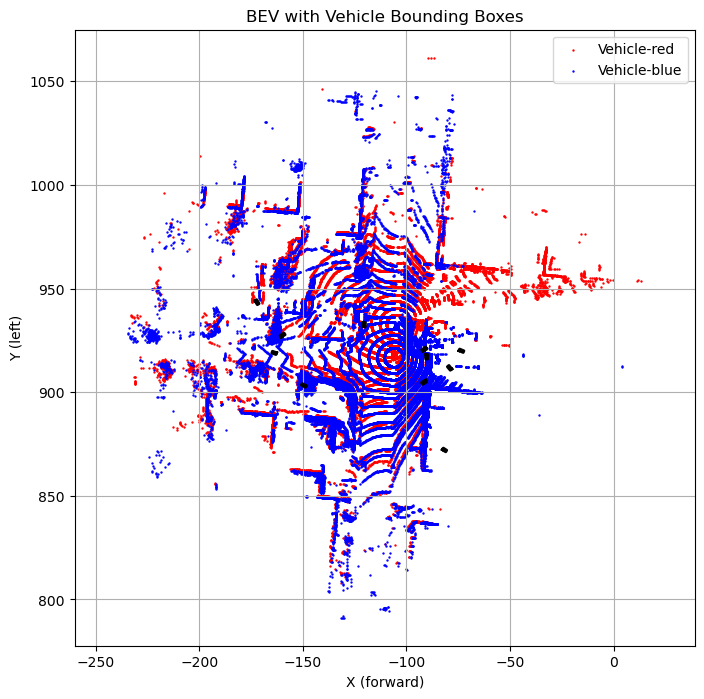

In [21]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from opencood.hypes_yaml.yaml_utils import load_yaml

def load_pose_from_yaml(yaml_path):
    data = load_yaml(yaml_path)
    pose = data['lidar_pose']
    if isinstance(pose, np.ndarray) and pose.shape == (4, 4):
        return pose
    elif isinstance(pose, list) and len(pose) == 6:
        return pose
    else:
        raise ValueError(f"Invalid lidar_pose shape: {np.array(pose).shape}")

def load_pcd_points(pcd_path):
    pcd = o3d.io.read_point_cloud(pcd_path)
    return np.asarray(pcd.points)

def transform_points_from_matrix(points, pose):
    """
    如果 pose 为 4x4 矩阵，则直接转换。
    如果 pose 为 [x,y,z,roll,yaw,pitch]（此处不讨论旋转，仅取位移部分），假设已经适配好，
    可自行构造 4x4 矩阵。此处演示 4x4 的情形：
    """
    if isinstance(pose, list):  # 如果是6维 pose，请先将其转换成矩阵（此处省略）
        raise NotImplementedError("请先转换6维 pose 到矩阵形式")
    N = points.shape[0]
    homo = np.hstack([points, np.ones((N,1))])
    transformed = (pose @ homo.T).T[:, :3]
    return transformed

def plot_bev_map(points_list, colors, title="BEV Map"):
    plt.figure(figsize=(8, 8))
    for points, color in zip(points_list, colors):
        plt.scatter(points[:, 0], points[:, 1], s=0.5, c=color, label=f"Vehicle-{color}")
    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.grid(True)
    # 不调用 plt.show() 以便后续叠加 bounding box
    # plt.show()

def create_bbox_corners(center, length, width, yaw):
    """
    根据车辆中心 (2,), 尺寸 length, width 以及 yaw(弧度)计算 BEV 下的四角
    返回 (5, 2) 数组，最后一个点与第一个点相同用于闭合轮廓
    """
    dx = length / 2.0
    dy = width / 2.0
    # 注意车体局部坐标系中，假设前方向为 x 正轴，侧向为 y 正轴
    # 四个角点相对中心
    corners_local = np.array([
        [ dx,  dy],
        [ dx, -dy],
        [-dx, -dy],
        [-dx,  dy],
        [ dx,  dy]  # 闭合轮廓
    ])
    # 旋转：生成 2x2 旋转矩阵
    R_mat = np.array([
        [np.cos(yaw), -np.sin(yaw)],
        [np.sin(yaw),  np.cos(yaw)]
    ])
    rotated_corners = (R_mat @ corners_local.T).T + center.reshape(1,2)
    return rotated_corners

def get_vehicle_bboxes(yaml_path, dataset_name):
    """
    从车辆 annotation 的 YAML 文件中提取 bounding box
    假设每个车辆的 annotation 存在于 YAML 的顶层字典中，键为车辆 id, 对应值为 dict, 包含：
      - location: [x, y, z]
      - extent: [length, width, height]
      - angle: [?, yaw, ?]  —— 取第二个作为 yaw (已统一单位为弧度)
    返回一个 list, 每个元素为 (5,2) 的 corners 数组
    """
    data = load_yaml(yaml_path)
    bboxes = []
    vehicle_dict = data['vehicles']
    for key, v in vehicle_dict.items():
        if isinstance(v, dict) and 'location' in v and 'extent' in v and 'angle' in v:
            # 使用 location 作为车辆绝对中心
            center = np.array(v['center'])
            location = np.array(v['location']) 
            abs_center = location + center
            center_bev = abs_center[:2]
            if dataset_name == 'v2v4real':
                lidar_pose_x = data['lidar_pose'][0, 3]
                lidar_pose_y = data['lidar_pose'][1, 3]
                center_bev += np.array([lidar_pose_x, lidar_pose_y])
            extent = np.array(v['extent'])
            l, w = extent[0], extent[1]
            # 对于 angle，取第二个元素作为 yaw；
            # 注意：OPV2V 的 yaw 是以度给出，可能需要转换成弧度
            # V2V4Real 的可能已经是弧度了。这里以简单例子展示：
            yaw = v['angle'][1]
            # 如果检测到 yaw 绝对值大于 2*pi，则认为单位为度，需要转换：
            # if abs(yaw) > 2 * np.pi:
            #     yaw = np.radians(yaw)
            bbox = create_bbox_corners(center_bev, l, w, yaw)
            bboxes.append(bbox)
    return bboxes

def plot_bev_with_bboxes(points_list, colors, bboxes_list, title="BEV with Bounding Boxes"):
    """
    在 BEV 图上叠加显示车辆 bounding box。
    points_list: list of point clouds, shape (N,3)
    colors: list of colors对应每辆车的点云
    bboxes_list: list of (5, 2) corners, 每辆车的 bounding box
    """
    plt.figure(figsize=(8, 8))
    # 绘制点云
    for points, color in zip(points_list, colors):
        plt.scatter(points[:, 0], points[:, 1], s=0.5, c=color, label=f"Vehicle-{color}")
    # 叠加 bounding box
    for bbox in bboxes_list:
        # bbox shape (5,2)，绘制闭合曲线
        plt.plot(bbox[:, 0], bbox[:, 1], 'k-', linewidth=2)
    plt.xlabel("X (forward)")
    plt.ylabel("Y (left)")
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.grid(True)
    plt.show()

# === 路径填写区域 (请根据你的数据设置修改) ===
# 这里使用 V2V4Real 示例数据路径
dataset_name = 'v2v4real'
pcd1_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/0/000146.pcd"
yaml1_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/0/000146.yaml"
pcd2_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/1/000146.pcd"
yaml2_path = "/home/labeling/datasets/v2v4real_data_dumping/testoutput_CAV_data_2022-03-17-10-50-46_0/1/000146.yaml"

# === 主流程 ===
# 加载 pose：这里 load_pose_from_yaml 返回的可为 4x4 matrix 或 6维向量
pose1 = load_pose_from_yaml(yaml1_path)
pose2 = load_pose_from_yaml(yaml2_path)
points1 = load_pcd_points(pcd1_path)
points2 = load_pcd_points(pcd2_path)

# 这里示例中假定 pose 为 4x4 matrix，否则需要转换6维 pose到 4x4。
points1_world = transform_points_from_matrix(points1, pose1)
points2_world = transform_points_from_matrix(points2, pose2)

# 加载 bounding box 信息：如果 yaml 中车辆 annotation 和 lidar_pose 在同一个文件中
# 此处分别使用两个 yaml 文件（假设每辆车的 annotation 存在对应的 YAML 文件中）
bboxes1 = get_vehicle_bboxes(yaml1_path, dataset_name)
bboxes2 = get_vehicle_bboxes(yaml2_path, dataset_name)
all_bboxes = bboxes1 + bboxes2

# 绘制 BEV 并叠加 bounding box
plot_bev_with_bboxes([points1_world, points2_world], colors=["red", "blue"], bboxes_list=all_bboxes,
                       title="BEV with Vehicle Bounding Boxes")


## Saved NPY file

In [4]:
import numpy as np
list(np.degrees([0,1.5, 0]))


[0.0, 85.94366926962348, 0.0]